# P3: Temporal Exploratory Data Analysis (EDA)
Fokus: Analisis Class Imbalance & Indikasi Concept Drift berbasis waktu.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load Data & Tinjauan Umum
Data `creditcard.csv` memiliki fitur waktu dalam hitungan detik (`Time`).

In [4]:
df = pd.read_csv('../data/raw/creditcard.csv')
print(f"Total Transaksi: {len(df):,}")
print(f"Total Fraud: {df['Class'].sum():,}")
print(f"Rasio Fraud: {df['Class'].mean() * 100:.3f}%")

Total Transaksi: 284,807
Total Fraud: 492
Rasio Fraud: 0.173%


## 2. Analisis Distribusi Waktu (Temporal Imbalance)
Kita konversi detik ke jam untuk melihat apakah fraud lebih sering terjadi di jam-jam tertentu (dinamika waktu).

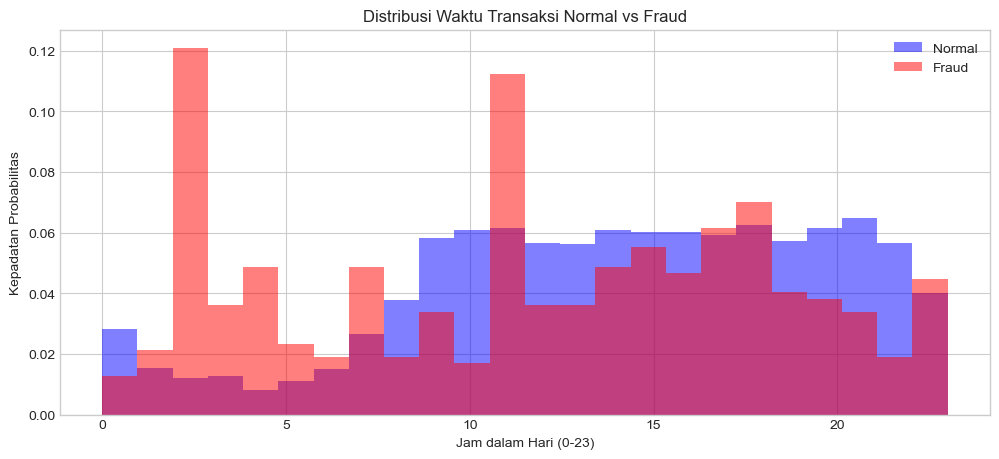

In [5]:
df['Hour'] = (df['Time'] / 3600).astype(int) % 24

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.hist(df[df['Class'] == 0]['Hour'], bins=24, color='blue', alpha=0.5, label='Normal', density=True)
ax1.hist(df[df['Class'] == 1]['Hour'], bins=24, color='red', alpha=0.5, label='Fraud', density=True)
ax1.set_xlabel('Jam dalam Hari (0-23)')
ax1.set_ylabel('Kepadatan Probabilitas')
ax1.set_title('Distribusi Waktu Transaksi Normal vs Fraud')
ax1.legend()
plt.show()

## 3. Indikasi Concept Drift (Pergeseran Fitur)
Kita membagi data menjadi batch kronologis (misal per 50.000 transaksi) lalu melihat apakah distribusi fitur kunci (misal `V4` atau `Amount`) berubah seiring waktu. Pergeseran ini merupakan bukti empiris keberadaan *Concept Drift*.

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


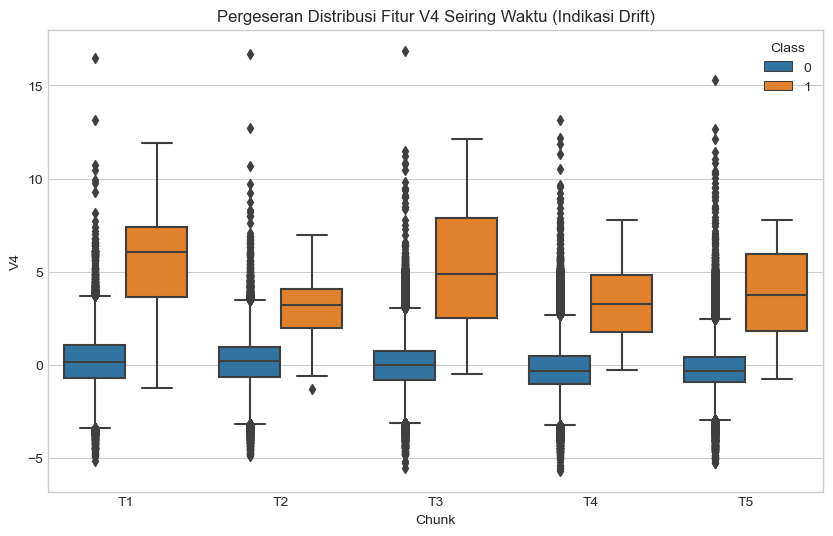

In [6]:
# Kita bagi menjadi 5 chunks waktu
df['Chunk'] = pd.qcut(df['Time'], q=5, labels=['T1', 'T2', 'T3', 'T4', 'T5'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='Chunk', y='V4', hue='Class', data=df)
plt.title('Pergeseran Distribusi Fitur V4 Seiring Waktu (Indikasi Drift)')
plt.show()